<a href="https://colab.research.google.com/github/sspark603/2025_02_AI/blob/main/week12_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import kagglehub

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.9.0+cu126


In [33]:
import os
import pandas as pd
import kagglehub


path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")


print(f"다운로드된 폴더 내 파일 목록: {os.listdir(path)}")


csv_file_name = 'Salary_dataset.csv'
full_file_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_file_path)

print(f"\n성공적으로 로드되었습니다! 데이터 모양: {df.shape}")
print(df.head())


Using Colab cache for faster access to the 'salary-dataset-simple-linear-regression' dataset.
다운로드된 폴더 내 파일 목록: ['Salary_dataset.csv']

성공적으로 로드되었습니다! 데이터 모양: (30, 3)
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0


In [34]:
# 3. 특징(X) 및 타겟(y) 설정
X = df[['YearsExperience']].values
y = df['Salary'].values.reshape(-1, 1)

# 4. 데이터 분리
# ★ y_test_original: 최종 평가 시 사용할, 스케일링되지 않은 원본 y_test
X_train, X_test, y_train, y_test_original = train_test_split(
    X, y, test_size=0.2, random_state=42
)
y_test = y_test_original.copy() # 스케일링을 위해 복사

# 5. 특징(X) 및 타겟(y) 스케일링 (★ y도 스케일링)
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# 6. PyTorch 텐서 변환 및 DataLoader 생성
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled) # X_test는 평가 시 CPU에 둬도 됩니다.
y_test_tensor = torch.FloatTensor(y_test_scaled).to(device)

batch_size = 4
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [43]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_size):
        super(LinearRegressionModel, self).__init__()

        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        return self.linear(x)

# 모델 초기화
input_size = X_train_scaled.shape[1]
model = LinearRegressionModel(input_size).to(device)
print("\n[모델 구조]")
print(model)


[모델 구조]
LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [48]:
# 하이퍼파라미터 및 설정 (이전과 동일)
learning_rate = 0.01
num_epochs = 800
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# ★ 손실 값을 저장할 리스트 초기화
train_losses = []
test_losses = []

print("\n\n---------------------")
print("Starting training (Recording Losses)...")
print("---------------------")

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

    # 에포크별 평균 훈련 손실 계산 및 저장
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss) # ★ 훈련 손실 저장

    # 테스트 (평가)
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, targets)
            test_loss += loss.item() * inputs.size(0)

    # 에포크별 평균 테스트 손실 계산 및 저장
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss) # ★ 테스트 손실 저장

    # 결과 출력
    if epoch % 200 == 0:
        print(f"Epoch [{epoch}/{num_epochs}] | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

print("----------------------------")
print("Training complete!")



---------------------
Starting training (Recording Losses)...
---------------------
Epoch [200/800] | Train Loss: 0.0356 | Test Loss: 0.0652
Epoch [400/800] | Train Loss: 0.0359 | Test Loss: 0.0653
Epoch [600/800] | Train Loss: 0.0357 | Test Loss: 0.0657
Epoch [800/800] | Train Loss: 0.0359 | Test Loss: 0.0657
----------------------------
Training complete!




🏆 최종 회귀 정확도 결과 🏆
R² Score (결정 계수):          0.9016
Root Mean Squared Error (RMSE): 7087.90
Mean Absolute Error (MAE):      6289.93


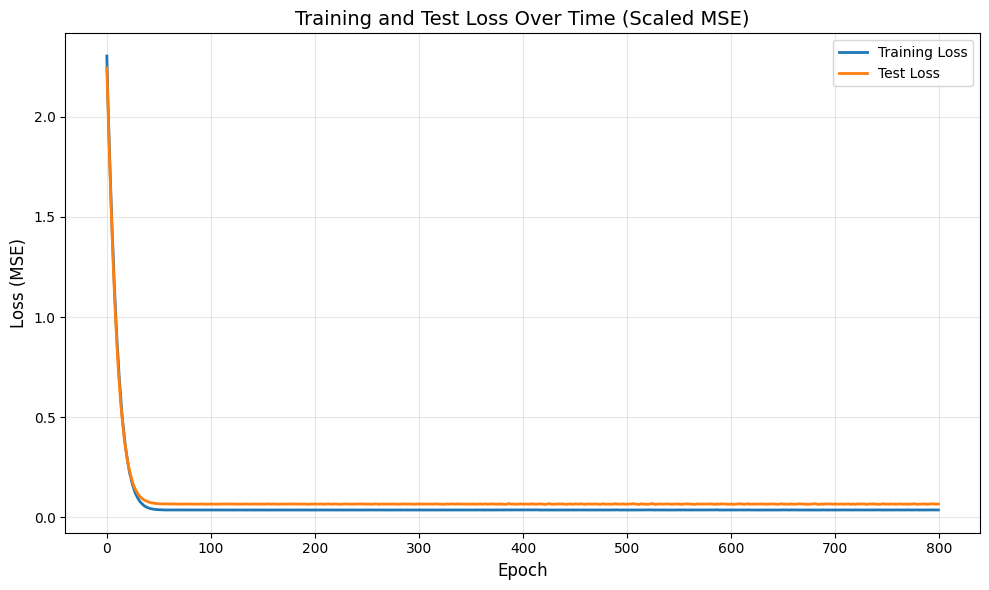

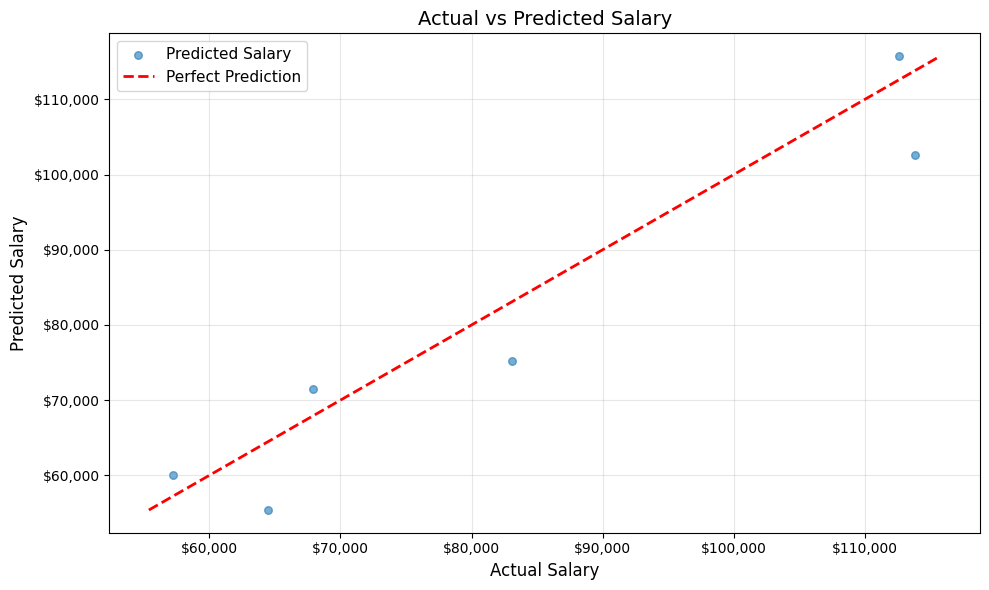

In [49]:
# 1. 테스트 세트 예측 및 역변환 (★ 핵심 수정)
model.eval()
all_outputs = []

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_outputs.append(outputs.cpu().numpy())


# 스케일링된 예측값과 실제값 합치기
y_pred_scaled = np.concatenate(all_outputs)


# ★ 스케일링된 값을 원래 연봉 단위로 되돌리기
y_pred = y_scaler.inverse_transform(y_pred_scaled).flatten()
y_true = y_test_original.flatten()


# 2. 회귀 지표 계산
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print("\n\n🏆 최종 회귀 정확도 결과 🏆")
print("=" * 50)
print(f"R² Score (결정 계수):          {r2:.4f}") # 이 값이 1에 가까워야 합니다.
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE):      {mae:.2f}")
print("=" * 50)


# 3. 손실 변화 시각화
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.title('Training and Test Loss Over Time (Scaled MSE)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. 예측값 vs 실제값 산점도
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.6, s=30, label='Predicted Salary')
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', lw=2, label='Perfect Prediction')

def currency_formatter(x, pos):
    return f'${int(x):,}'

formatter = FuncFormatter(currency_formatter)
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xlabel('Actual Salary', fontsize=12)
plt.ylabel('Predicted Salary', fontsize=12)
plt.title('Actual vs Predicted Salary', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()